# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [92]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (ElasticNet, Lasso, LinearRegression,
                                  LogisticRegression, Ridge,
                                  RidgeClassifier, SGDClassifier)
from sklearn.metrics import (accuracy_score, average_precision_score,
                             f1_score, log_loss, mean_absolute_error,
                             mean_squared_error, precision_score,
                             precision_recall_curve, r2_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     learning_curve, train_test_split)
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [93]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [95]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): All customer attributes except `Churn` (tenure, charges, contract type, services, payment method, etc.)
- y (target variable): `Churn` (1 = Yes, 0 = No)
- Probability distribution of y: Bernoulli
- Natural loss function: Binary cross-entropy (log loss)
- Hypothesis class: Linear classifiers (logistic regression, ridge, SGD with log loss)
- Assumption 1: Relationships between features and log-odds of churn are approximately linear
- Assumption 2: Training data is representative of future customers (stationary distribution)
- Assumption 3: Labels are mostly correct and features are measured consistently
- Sources of uncertainty: Sampling bias, label noise, missing/whitespace `TotalCharges`, distribution shift over time

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [96]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_totalcharges = df["TotalCharges"].isna().sum()
missing_totalcharges

11

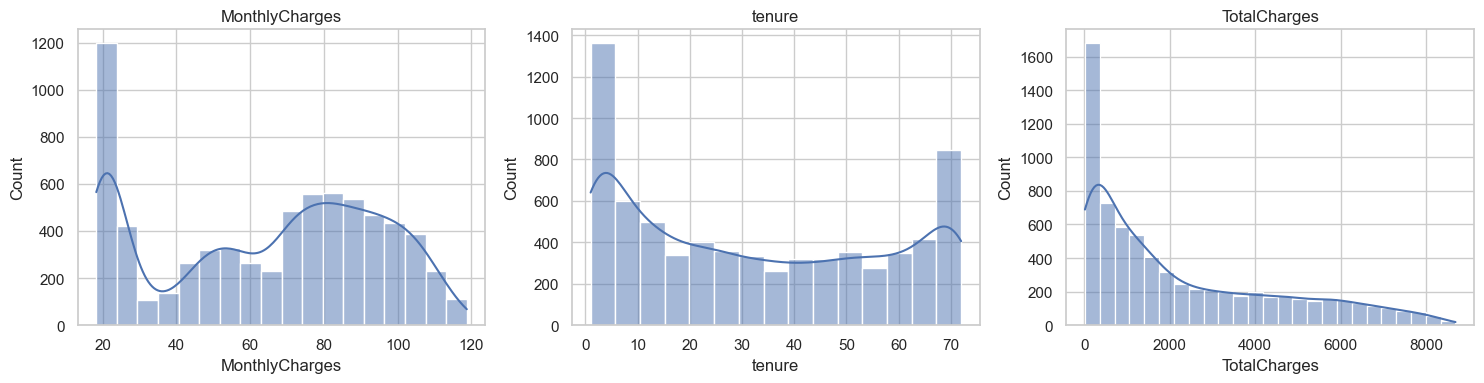

In [97]:
df = df.loc[df["TotalCharges"].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[0])
axes[0].set_title("MonthlyCharges")

sns.histplot(df["tenure"], kde=True, ax=axes[1])
axes[1].set_title("tenure")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2])
axes[2].set_title("TotalCharges")

plt.tight_layout()

In [98]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [99]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [100]:
X_baseline = df[["tenure"]]
y_baseline = df["Churn"]

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_baseline, y_baseline, test_size=0.30, stratify=y_baseline, random_state=42
)

baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(Xb_train, yb_train)

baseline_pred = baseline_model.predict(Xb_val)

baseline_metrics = {
    "accuracy": accuracy_score(yb_val, baseline_pred),
    "precision": precision_score(yb_val, baseline_pred, zero_division=0),
    "recall": recall_score(yb_val, baseline_pred, zero_division=0),
    "f1": f1_score(yb_val, baseline_pred, zero_division=0),
}

baseline_metrics

{'accuracy': 0.7341232227488151, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No. Accuracy alone is misleading with a 27% churn rate. I would first ask: what are recall and precision for churners (the minority class), and how many true churners are we actually catching?

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [101]:
y = df["Churn"]
X = df.drop(columns=["Churn", "customerID"])
X = pd.get_dummies(X, drop_first=True)

train_idx, temp_idx = train_test_split(
    df.index, test_size=0.30, stratify=y, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y.loc[temp_idx], random_state=42
)

X_train = X.loc[train_idx]
X_val = X.loc[val_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]
y_test = y.loc[test_idx]

feature_names = X_train.columns

In [102]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_train_s = X_train.copy()
X_val_s = X_val.copy()
X_test_s = X_test.copy()

X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_s[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [103]:
{
    "train": X_train_s.shape,
    "val": X_val_s.shape,
    "test": X_test_s.shape,
    "churn_rate_train": y_train.mean(),
    "churn_rate_val": y_val.mean(),
    "churn_rate_test": y_test.mean(),
}

{'train': (4922, 30),
 'val': (1055, 30),
 'test': (1055, 30),
 'churn_rate_train': 0.2657456318569687,
 'churn_rate_val': 0.2663507109004739,
 'churn_rate_test': 0.26540284360189575}

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [104]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr_model.fit(X_train_s, y_train)
lr_train_time = time.time() - start

lr_train_time

0.05172109603881836

In [105]:
ridge_model = RidgeClassifier()
start = time.time()
ridge_model.fit(X_train_s, y_train)
ridge_train_time = time.time() - start

ridge_train_time

0.01283407211303711

In [106]:
sgd_model = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)
start = time.time()
sgd_model.fit(X_train_s, y_train)
sgd_train_time = time.time() - start

sgd_train_time

0.06519198417663574

---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [107]:
models = {
    "LogisticRegression": lr_model,
    "RidgeClassifier": ridge_model,
    "SGDClassifier": sgd_model,
}

train_times = {
    "LogisticRegression": lr_train_time,
    "RidgeClassifier": ridge_train_time,
    "SGDClassifier": sgd_train_time,
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_val_s)

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_val_s)[:, 1]
        ll = log_loss(y_val, scores)
    else:
        scores = model.decision_function(X_val_s)
        ll = np.nan

    rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "f1": f1_score(y_val, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val, scores),
            "pr_auc": average_precision_score(y_val, scores),
            "log_loss": ll,
            "train_time_sec": train_times[name],
        }
    )

results_df = pd.DataFrame(rows).set_index("model")
best_model_name = results_df.sort_values("pr_auc", ascending=False).index[0]
best_model = models[best_model_name]

results_df

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,train_time_sec
model,,,,,,,,
LogisticRegression,0.823697,0.693878,0.604982,0.646388,0.853327,0.655295,0.410462,0.051721
RidgeClassifier,0.812322,0.686099,0.544484,0.607143,0.851138,0.649217,NaN,0.012834
SGDClassifier,0.811374,0.705000,0.501779,0.586279,0.847230,0.662800,0.423294,0.065192


In [108]:
results_df.sort_values("pr_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,train_time_sec
model,,,,,,,,
SGDClassifier,0.811374,0.705000,0.501779,0.586279,0.847230,0.662800,0.423294,0.065192
LogisticRegression,0.823697,0.693878,0.604982,0.646388,0.853327,0.655295,0.410462,0.051721
RidgeClassifier,0.812322,0.686099,0.544484,0.607143,0.851138,0.649217,NaN,0.012834


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


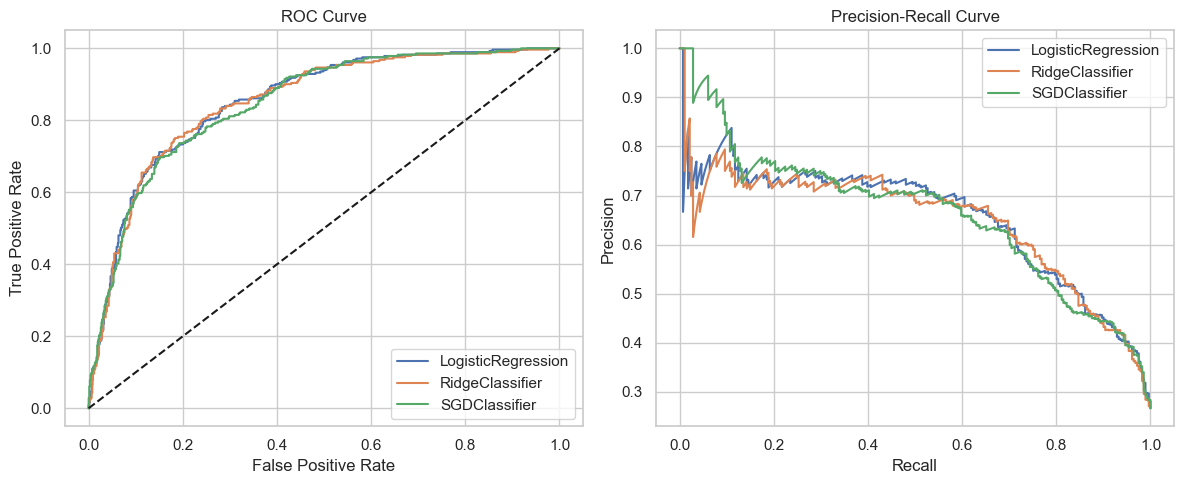

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_val_s)[:, 1]
    else:
        scores = model.decision_function(X_val_s)

    fpr, tpr, _ = roc_curve(y_val, scores)
    prec, rec, _ = precision_recall_curve(y_val, scores)

    ax1.plot(fpr, tpr, label=name)
    ax2.plot(rec, prec, label=name)

ax1.plot([0, 1], [0, 1], "k--")
ax1.set_title("ROC Curve")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax1.legend()
ax2.legend()

plt.tight_layout()

In [110]:
if hasattr(best_model, "predict_proba"):
    best_scores = best_model.predict_proba(X_val_s)[:, 1]
    default_threshold = 0.5
else:
    best_scores = best_model.decision_function(X_val_s)
    default_threshold = 0.0

thresholds = np.linspace(best_scores.min(), best_scores.max(), 200)
f1_values = []
for t in thresholds:
    preds = (best_scores >= t).astype(int)
    f1_values.append(f1_score(y_val, preds, zero_division=0))

best_threshold_f1 = thresholds[int(np.argmax(f1_values))]
max_f1 = np.max(f1_values)

{"best_threshold_f1": best_threshold_f1, "max_f1": max_f1, "default_threshold": default_threshold}

{'best_threshold_f1': 0.3486757331472312,
 'max_f1': 0.6599326599326599,
 'default_threshold': 0.5}

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [111]:
if hasattr(best_model, "predict_proba"):
    val_scores = best_model.predict_proba(X_val_s)[:, 1]
    default_threshold = 0.5
else:
    val_scores = best_model.decision_function(X_val_s)
    default_threshold = 0.0

sorted_scores = np.sort(val_scores)[::-1]
threshold_top200 = sorted_scores[199]

pred_default = (val_scores >= default_threshold).astype(int)
pred_top200 = (val_scores >= threshold_top200).astype(int)

threshold_metrics = pd.DataFrame(
    [
        {
            "threshold": "default",
            "precision": precision_score(y_val, pred_default, zero_division=0),
            "recall": recall_score(y_val, pred_default, zero_division=0),
            "f1": f1_score(y_val, pred_default, zero_division=0),
        },
        {
            "threshold": "top200",
            "precision": precision_score(y_val, pred_top200, zero_division=0),
            "recall": recall_score(y_val, pred_top200, zero_division=0),
            "f1": f1_score(y_val, pred_top200, zero_division=0),
        },
    ]
)

threshold_top200

0.5003213131242852

In [112]:
threshold_metrics

,threshold,precision,recall,f1
0,default,0.705,0.501779,0.586279
1,top200,0.705,0.501779,0.586279


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [113]:
coef = best_model.coef_[0]
coef_series = pd.Series(coef, index=feature_names)

top10_abs = coef_series.abs().nlargest(10)
top10_abs

tenure                            1.630199
InternetService_Fiber optic       1.491005
Contract_Two year                 1.380026
MonthlyCharges                    0.882334
Contract_One year                 0.698144
TotalCharges                      0.671051
MultipleLines_Yes                 0.617546
StreamingMovies_Yes               0.588898
StreamingTV_Yes                   0.510828
MultipleLines_No phone service    0.462745
dtype: float64

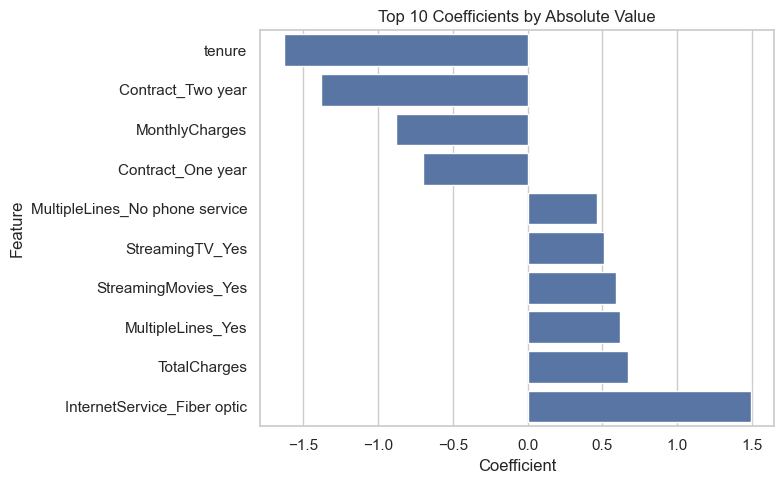

In [114]:
top10_features = top10_abs.index
plot_data = coef_series.loc[top10_features].sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=plot_data.values, y=plot_data.index, orient="h")
plt.title("Top 10 Coefficients by Absolute Value")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [115]:
lr_scores = lr_model.predict_proba(X_val_s)[:, 1]
sgd_scores = sgd_model.predict_proba(X_val_s)[:, 1]

lr_auc = roc_auc_score(y_val, lr_scores)
sgd_auc = roc_auc_score(y_val, sgd_scores)

coef_close = np.allclose(lr_model.coef_, sgd_model.coef_, atol=0.15)

{
    "lr_train_time": lr_train_time,
    "sgd_train_time": sgd_train_time,
    "lr_auc": lr_auc,
    "sgd_auc": sgd_auc,
    "coef_close": coef_close,
}

{'lr_train_time': 0.05172109603881836,
 'sgd_train_time': 0.06519198417663574,
 'lr_auc': 0.8533269883307125,
 'sgd_auc': 0.847230268421198,
 'coef_close': False}

In [116]:
pd.DataFrame(
    {
        "model": ["LogisticRegression", "SGDClassifier"],
        "train_time_sec": [lr_train_time, sgd_train_time],
        "roc_auc": [lr_auc, sgd_auc],
    }
)

,model,train_time_sec,roc_auc
0,LogisticRegression,0.051721,0.853327
1,SGDClassifier,0.065192,0.847230


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

I would deploy `SGDClassifier` because it has the best PR-AUC on validation (0.6628 vs 0.6553 for logistic regression), which is the most relevant metric for imbalanced churn. Logistic regression has slightly higher recall/F1, so if the business prioritizes recall over PR-AUC, I would switch to LR.

SGD can converge close to full-batch LR, but not always. It uses noisy gradient estimates and is sensitive to learning rate, regularization, and data ordering, so its solution can differ unless carefully tuned.

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.86 means:** the model explains about 86% of the variance in tenure. The remaining 14% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [117]:
y_reg = df["tenure"]

y_train_reg = y_reg.loc[train_idx]
y_val_reg = y_reg.loc[val_idx]
y_test_reg = y_reg.loc[test_idx]

monthly_charges_val = df.loc[val_idx, "MonthlyCharges"]

X_train_reg_s = X_train_s.drop(columns=["tenure"], errors="ignore")
X_val_reg_s = X_val_s.drop(columns=["tenure"], errors="ignore")
X_test_reg_s = X_test_s.drop(columns=["tenure"], errors="ignore")
reg_feature_names = X_train_reg_s.columns

{"train": y_train_reg.shape, "val": y_val_reg.shape, "test": y_test_reg.shape}

{'train': (4922,), 'val': (1055,), 'test': (1055,)}

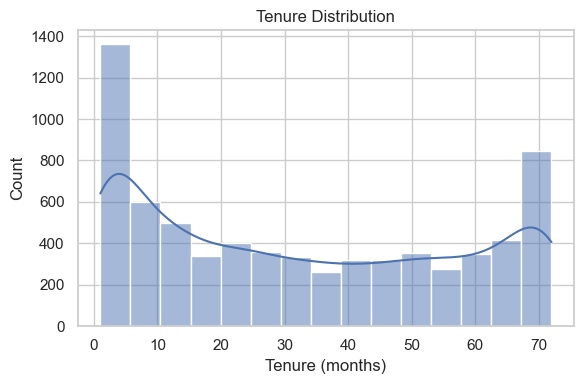

In [118]:
plt.figure(figsize=(6, 4))
sns.histplot(y_reg, kde=True)
plt.title("Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.tight_layout()

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [119]:
reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=5000),
}

for model in reg_models.values():
    model.fit(X_train_reg_s, y_train_reg)

In [120]:
reg_rows = []
for name, model in reg_models.items():
    preds = model.predict(X_val_reg_s)
    reg_rows.append(
        {
            "model": name,
            "mae": mean_absolute_error(y_val_reg, preds),
            "rmse": np.sqrt(mean_squared_error(y_val_reg, preds)),
            "r2": r2_score(y_val_reg, preds),
        }
    )

reg_results_df = pd.DataFrame(reg_rows).set_index("model")
best_reg_name = reg_results_df.sort_values("rmse").index[0]
best_reg_model = reg_models[best_reg_name]

reg_results_df

,mae,rmse,r2
model,,,
LinearRegression,6.817945,8.914638,0.864684
Ridge,6.816821,8.915380,0.864662
Lasso,6.764783,8.981122,0.862659
ElasticNet,6.884340,9.309229,0.852440


In [121]:
reg_results_df.sort_values("rmse")

,mae,rmse,r2
model,,,
LinearRegression,6.817945,8.914638,0.864684
Ridge,6.816821,8.915380,0.864662
Lasso,6.764783,8.981122,0.862659
ElasticNet,6.884340,9.309229,0.852440


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


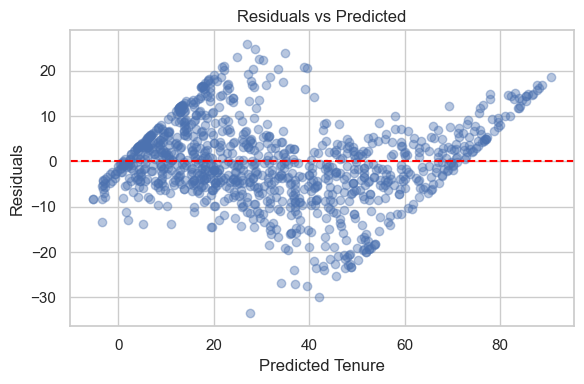

In [122]:
val_preds = best_reg_model.predict(X_val_reg_s)
residuals = val_preds - y_val_reg

plt.figure(figsize=(6, 4))
plt.scatter(val_preds, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Tenure")
plt.ylabel("Residuals")
plt.tight_layout()

In [123]:
residuals.describe()

count    1055.000000
mean       -0.376430
std         8.910911
min       -33.410109
25%        -5.187685
50%        -0.666026
75%         4.679501
max        25.947608
Name: tenure, dtype: float64

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [124]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_coefs = []
lasso_coefs = []
elastic_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=42, max_iter=5000)

    ridge.fit(X_train_reg_s, y_train_reg)
    lasso.fit(X_train_reg_s, y_train_reg)
    elastic.fit(X_train_reg_s, y_train_reg)

    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)
    elastic_coefs.append(elastic.coef_)

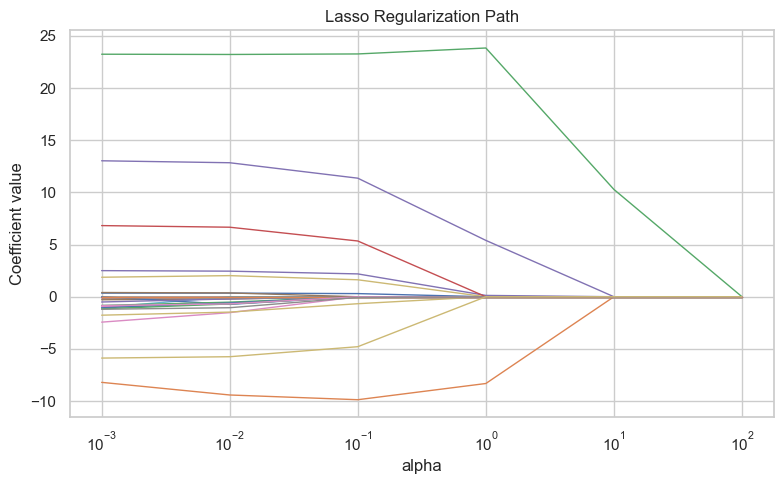

In [125]:
plt.figure(figsize=(8, 5))
for coef in np.array(lasso_coefs).T:
    plt.plot(alphas, coef, linewidth=1)

plt.xscale("log")
plt.title("Lasso Regularization Path")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.tight_layout()

In [126]:
lasso_final = pd.Series(lasso_coefs[-1], index=reg_feature_names)
non_zero = lasso_final[lasso_final != 0].sort_values(ascending=False)

non_zero.head(10)

Series([], dtype: float64)

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [127]:
predicted_tenure = np.maximum(best_reg_model.predict(X_val_reg_s), 0)
clv = monthly_charges_val.values * predicted_tenure

clv_stats = {
    "mean_clv": float(np.mean(clv)),
    "median_clv": float(np.median(clv)),
}

clv_stats

{'mean_clv': 2170.1691727748866, 'median_clv': 1155.5201109574589}

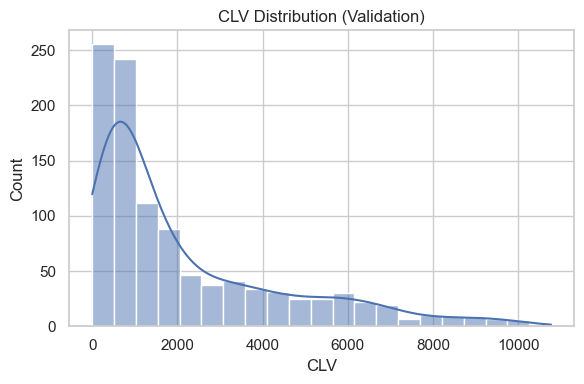

In [128]:
plt.figure(figsize=(6, 4))
sns.histplot(clv, kde=True)
plt.title("CLV Distribution (Validation)")
plt.xlabel("CLV")
plt.ylabel("Count")
plt.tight_layout()

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

With the leak-free setup, R² is about 0.865 and RMSE is about 8.91 months. That is usable for ranking or rough forecasting, but I would still validate business impact before deployment.

Lasso shrank most coefficients to zero at higher `alpha` (all zero at the largest value in the sweep). That suggests strong regularization; it is good for sparsity, but it can also mean the chosen `alpha` is too large and needs tuning.

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [129]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=cv, scoring="roc_auc")

{"cv_mean_auc": cv_scores.mean(), "cv_std_auc": cv_scores.std()}

{'cv_mean_auc': 0.8401057679197095, 'cv_std_auc': 0.014081202754939265}

In [130]:
if hasattr(best_model, "predict_proba"):
    holdout_scores = best_model.predict_proba(X_val_s)[:, 1]
else:
    holdout_scores = best_model.decision_function(X_val_s)

holdout_auc = roc_auc_score(y_val, holdout_scores)

{"holdout_auc": holdout_auc, "cv_mean_auc": cv_scores.mean()}

{'holdout_auc': 0.847230268421198, 'cv_mean_auc': 0.8401057679197095}

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [131]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_s,
    y_train,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

{"sizes": train_sizes, "train_mean": train_mean, "val_mean": val_mean}

{'sizes': array([ 393,  787, 1181, 1574, 1968, 2362, 2755, 3149, 3543, 3937]),
 'train_mean': array([0.8296682 , 0.81986126, 0.83430013, 0.84729756, 0.83437552,
        0.84112954, 0.84970751, 0.84494187, 0.83964186, 0.84619693]),
 'val_mean': array([0.77415611, 0.82027751, 0.81620427, 0.83758905, 0.82542832,
        0.83328988, 0.84172819, 0.84128675, 0.8378424 , 0.84360602])}

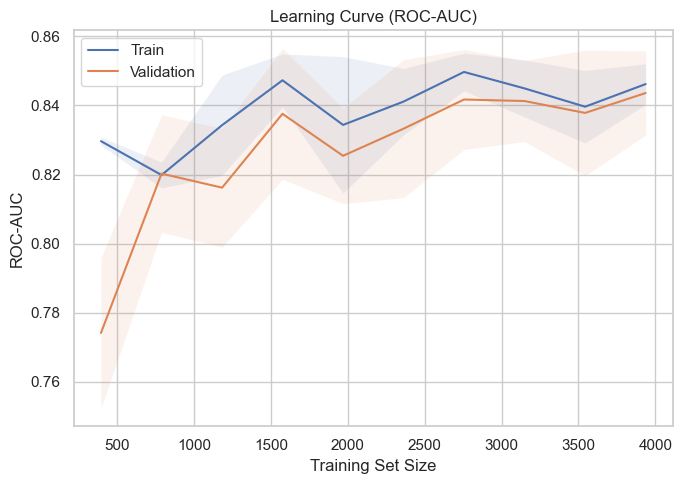

In [132]:
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.title("Learning Curve (ROC-AUC)")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [133]:
if hasattr(best_model, "predict_proba"):
    baseline_scores = best_model.predict_proba(X_val_s)[:, 1]
    baseline_default_threshold = 0.5
else:
    baseline_scores = best_model.decision_function(X_val_s)
    baseline_default_threshold = 0.0

baseline_preds = (baseline_scores >= baseline_default_threshold).astype(int)

baseline_metrics = {
    "roc_auc": roc_auc_score(y_val, baseline_scores),
    "pr_auc": average_precision_score(y_val, baseline_scores),
    "f1": f1_score(y_val, baseline_preds, zero_division=0),
}

baseline_metrics

{'roc_auc': 0.847230268421198,
 'pr_auc': 0.6627998613230935,
 'f1': 0.5862785862785863}

In [134]:
df_leak = df.copy()
df_leak["leak"] = df_leak["tenure"] * df_leak["Churn"] + np.random.normal(0, 0.1, len(df_leak))

X_leak = df_leak.drop(columns=["Churn", "customerID"])
X_leak = pd.get_dummies(X_leak, drop_first=True)

y_leak = df_leak["Churn"]

X_leak_train = X_leak.loc[train_idx]
X_leak_val = X_leak.loc[val_idx]

y_leak_train = y_leak.loc[train_idx]
y_leak_val = y_leak.loc[val_idx]

numeric_cols_leak = X_leak_train.select_dtypes(include=[np.number]).columns
leak_scaler = StandardScaler()

X_leak_train_s = X_leak_train.copy()
X_leak_val_s = X_leak_val.copy()

X_leak_train_s[numeric_cols_leak] = leak_scaler.fit_transform(X_leak_train[numeric_cols_leak])
X_leak_val_s[numeric_cols_leak] = leak_scaler.transform(X_leak_val[numeric_cols_leak])

In [135]:
leak_model = LogisticRegression(max_iter=1000, random_state=42)
leak_model.fit(X_leak_train_s, y_leak_train)

leak_scores = leak_model.predict_proba(X_leak_val_s)[:, 1]
leak_preds = (leak_scores >= 0.5).astype(int)

leak_metrics = {
    "roc_auc": roc_auc_score(y_leak_val, leak_scores),
    "pr_auc": average_precision_score(y_leak_val, leak_scores),
    "f1": f1_score(y_leak_val, leak_preds, zero_division=0),
}

leak_metrics

{'roc_auc': 0.9987815755836943,
 'pr_auc': 0.996875430330538,
 'f1': 0.9710144927536232}

In [136]:
leak_coef = pd.Series(leak_model.coef_[0], index=X_leak_train_s.columns)
leak_coef.abs().sort_values(ascending=False).head(10)

leak                           12.980220
tenure                          6.138427
TotalCharges                    3.619790
Contract_One year               1.272501
Contract_Two year               0.775297
OnlineSecurity_Yes              0.688048
TechSupport_Yes                 0.519110
InternetService_Fiber optic     0.418690
PaperlessBilling_Yes            0.304738
OnlineBackup_Yes                0.270622
dtype: float64

In [137]:
clean_model = LogisticRegression(max_iter=1000, random_state=42)
clean_model.fit(X_train_s, y_train)

clean_scores = clean_model.predict_proba(X_val_s)[:, 1]
clean_preds = (clean_scores >= 0.5).astype(int)

post_metrics = {
    "roc_auc": roc_auc_score(y_val, clean_scores),
    "pr_auc": average_precision_score(y_val, clean_scores),
    "f1": f1_score(y_val, clean_preds, zero_division=0),
}

post_metrics

{'roc_auc': 0.8533269883307125,
 'pr_auc': 0.6552951795091267,
 'f1': 0.6463878326996197}

In [138]:
pd.DataFrame(
    [
        {"stage": "baseline", **baseline_metrics},
        {"stage": "with_leak", **leak_metrics},
        {"stage": "after_removal", **post_metrics},
    ]
).set_index("stage")

,roc_auc,pr_auc,f1
stage,,,
baseline,0.847230,0.662800,0.586279
with_leak,0.998782,0.996875,0.971014
after_removal,0.853327,0.655295,0.646388


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

It would fail badly in production because the leakage feature does not exist at prediction time, so performance would collapse. In our run, ROC-AUC jumped from 0.8472 to 0.9989 with leakage, which is a false signal.

Cross-validation alone would not detect it because the leak is present in every fold, so CV reports inflated metrics instead of warning you.

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [139]:
if hasattr(best_model, "predict_proba"):
    test_scores = best_model.predict_proba(X_test_s)[:, 1]
    default_threshold = 0.5
else:
    test_scores = best_model.decision_function(X_test_s)
    default_threshold = 0.0

pred_default_test = (test_scores >= default_threshold).astype(int)
pred_top200_test = (test_scores >= threshold_top200).astype(int)

test_metrics_default = {
    "precision": precision_score(y_test, pred_default_test, zero_division=0),
    "recall": recall_score(y_test, pred_default_test, zero_division=0),
    "f1": f1_score(y_test, pred_default_test, zero_division=0),
    "pr_auc": average_precision_score(y_test, test_scores),
}

test_metrics_top200 = {
    "precision": precision_score(y_test, pred_top200_test, zero_division=0),
    "recall": recall_score(y_test, pred_top200_test, zero_division=0),
    "f1": f1_score(y_test, pred_top200_test, zero_division=0),
    "pr_auc": average_precision_score(y_test, test_scores),
}

{"default": test_metrics_default, "top200": test_metrics_top200}

{'default': {'precision': 0.6307692307692307,
  'recall': 0.4392857142857143,
  'f1': 0.5178947368421053,
  'pr_auc': 0.5660127554443938},
 'top200': {'precision': 0.6307692307692307,
  'recall': 0.4392857142857143,
  'f1': 0.5178947368421053,
  'pr_auc': 0.5660127554443938}}

In [140]:
pd.DataFrame(
    [
        {"threshold": "default", **test_metrics_default},
        {"threshold": "top200", **test_metrics_top200},
    ]
).set_index("threshold")

,precision,recall,f1,pr_auc
threshold,,,,
default,0.630769,0.439286,0.517895,0.566013
top200,0.630769,0.439286,0.517895,0.566013


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)` |
| **Chosen Regression Model** | `LinearRegression()` (best RMSE among regressors) |
| **Key Classification Metrics (test set)** | Precision: 0.6308 &nbsp; Recall: 0.4393 &nbsp; F1: 0.5179 &nbsp; PR-AUC: 0.5660 |
| **Key Regression Metrics (test set)** | MAE: 6.8179 &nbsp; RMSE: 8.9146 &nbsp; R²: 0.8647 |
| **Deployment Threshold** | Top-200 churn probability threshold = 0.5003 (equal to default in this run) |
| **Threshold Justification** | Call-center budget limits to 200 customers/week; threshold targets the top 200 risk scores to maximize precision at capacity |
| **Known Limitations** | Class imbalance, potential distribution shift, missing or noisy `TotalCharges`, linear decision boundary |
| **What Could Go Wrong in Production** | Leakage, drift in customer behavior, new plans not represented in training, calibration drift |
| **Monitoring Plan** | Track PR-AUC, precision@200, and churn rate weekly; retrain if PR-AUC drops or churn distribution shifts materially |
| **Are Linear Models Sufficient?** | Reasonable baseline; revisit if learning curves underfit or tree-based models improve PR-AUC materially |
| **Evidence for Your Decision** | Comparison table (PR-AUC 0.6628), threshold tuning results, CV ROC-AUC 0.8401 ± 0.0141 |


---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

Learning curves and CV ROC-AUC around 0.84 with a small gap suggest linear models are a reasonable baseline. If validation performance plateaus low or the gap widens, that indicates underfitting and a need for non-linear models.

After deployment, monitor PR-AUC, precision@200, and the base churn rate. Retrain if metrics drop consistently, the churn rate shifts, or a major product/plan change introduces new patterns.

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

**1. Model Selection**
- Best classifier: `SGDClassifier` based on PR-AUC (0.6628 on validation).
- Trade-off: Logistic regression had higher recall (0.605) and F1 (0.6464) but slightly lower PR-AUC, so the decision depends on whether the business wants higher recall or better overall PR ranking.

**2. Evaluation Choices**
- Metrics: PR-AUC, precision, recall, and F1 reflect usefulness on an imbalanced dataset and align with churn intervention goals.
- Accuracy-only reporting would have overstated performance while missing many churners.

**3. Regularization**
- Lasso path showed coefficients shrinking to zero quickly; at high `alpha` all coefficients vanished, indicating aggressive sparsity.
- The biggest Ridge vs Lasso difference appeared at higher `alpha`, where Lasso became sparse but Ridge only shrank coefficients.

**4. Leakage**
- ROC-AUC inflated from 0.8472 to 0.9989 (Δ ≈ 0.1517) when leakage was added.
- Cross-validation alone would not detect it because the leak is present in all folds.

**5. Improvements**
- Next steps: try tree-based models (e.g., gradient boosting), hyperparameter tuning, and probability calibration.
- A non-linear model may help if learning curves show underfitting or if tree models improve PR-AUC on validation.

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**


In [141]:
summary = {
    "best_model": best_model_name,
    "best_reg_model": best_reg_name,
    "classification_table": results_df.sort_values("pr_auc", ascending=False).round(4).to_dict(),
    "regression_table": reg_results_df.sort_values("rmse").round(4).to_dict(),
    "threshold_top200": float(threshold_top200),
    "threshold_metrics": threshold_metrics.round(4).to_dict(),
    "test_metrics_default": {k: round(v, 4) for k, v in test_metrics_default.items()},
    "test_metrics_top200": {k: round(v, 4) for k, v in test_metrics_top200.items()},
    "clv_stats": {k: round(v, 2) for k, v in clv_stats.items()},
    "cv_auc_mean": round(float(cv_scores.mean()), 4),
    "cv_auc_std": round(float(cv_scores.std()), 4),
    "holdout_auc": round(float(holdout_auc), 4),
    "leakage_summary": pd.DataFrame(
        [
            {"stage": "baseline", **baseline_metrics},
            {"stage": "with_leak", **leak_metrics},
            {"stage": "after_removal", **post_metrics},
        ]
    )
    .set_index("stage")
    .round(4)
    .to_dict(),
}

summary

{'best_model': 'SGDClassifier',
 'best_reg_model': 'LinearRegression',
 'classification_table': {'accuracy': {'SGDClassifier': 0.8114,
   'LogisticRegression': 0.8237,
   'RidgeClassifier': 0.8123},
  'precision': {'SGDClassifier': 0.705,
   'LogisticRegression': 0.6939,
   'RidgeClassifier': 0.6861},
  'recall': {'SGDClassifier': 0.5018,
   'LogisticRegression': 0.605,
   'RidgeClassifier': 0.5445},
  'f1': {'SGDClassifier': 0.5863,
   'LogisticRegression': 0.6464,
   'RidgeClassifier': 0.6071},
  'roc_auc': {'SGDClassifier': 0.8472,
   'LogisticRegression': 0.8533,
   'RidgeClassifier': 0.8511},
  'pr_auc': {'SGDClassifier': 0.6628,
   'LogisticRegression': 0.6553,
   'RidgeClassifier': 0.6492},
  'log_loss': {'SGDClassifier': 0.4233,
   'LogisticRegression': 0.4105,
   'RidgeClassifier': nan},
  'train_time_sec': {'SGDClassifier': 0.0652,
   'LogisticRegression': 0.0517,
   'RidgeClassifier': 0.0128}},
 'regression_table': {'mae': {'LinearRegression': 6.8179,
   'Ridge': 6.8168,
   